In [1]:
import pandas as pd

In [3]:
USD_data = pd.read_excel('/Users/yitik/Desktop/Dersler/For Python/InvestGuide/investment_ml/rawData/USD_rawDataset.xlsx')
df = USD_data.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1238 entries, 0 to 1237
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Tarih          1238 non-null   object 
 1   Yıl            1238 non-null   int64  
 2   Ay             1238 non-null   int64  
 3   Alış (Forex)   1238 non-null   float64
 4   Satış (Forex)  1238 non-null   float64
dtypes: float64(2), int64(2), object(1)
memory usage: 48.5+ KB


In [5]:
df.head()

,Tarih,Yıl,Ay,Alış (Forex),Satış (Forex)
0,2020-12-07,2020,12,7.8373,7.8514
1,2020-12-08,2020,12,7.8087,7.8227
2,2020-12-09,2020,12,7.8203,7.8344
3,2020-12-10,2020,12,7.8499,7.8640
4,2020-12-11,2020,12,7.9349,7.9492


In [7]:
df['Gun'] = df['Tarih'].apply(lambda x: int(x[-2:]))

In [9]:
df.Gun

0        7
1        8
2        9
3       10
4       11
        ..
1233     1
1234     2
1235     3
1236     4
1237     5
Name: Gun, Length: 1238, dtype: int64

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1238 entries, 0 to 1237
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Tarih          1238 non-null   object 
 1   Yıl            1238 non-null   int64  
 2   Ay             1238 non-null   int64  
 3   Alış (Forex)   1238 non-null   float64
 4   Satış (Forex)  1238 non-null   float64
 5   Gun            1238 non-null   int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 58.2+ KB


In [59]:
df['Tarih'] = pd.to_datetime(df['Tarih'])
df = df.sort_values(by = 'Tarih')
df = df.reset_index(drop=True)

In [19]:
df.head()

,Tarih,Yıl,Ay,Alış (Forex),Satış (Forex),Gun
0,2020-12-07,2020,12,7.8373,7.8514,7
1,2020-12-08,2020,12,7.8087,7.8227,8
2,2020-12-09,2020,12,7.8203,7.8344,9
3,2020-12-10,2020,12,7.8499,7.8640,10
4,2020-12-11,2020,12,7.9349,7.9492,11


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1238 entries, 0 to 1237
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Tarih          1238 non-null   datetime64[ns]
 1   Yıl            1238 non-null   int64         
 2   Ay             1238 non-null   int64         
 3   Alış (Forex)   1238 non-null   float64       
 4   Satış (Forex)  1238 non-null   float64       
 5   Gun            1238 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(3)
memory usage: 58.2 KB


In [23]:
df['Haftalik_Ortalama'] = df['Alış (Forex)'].rolling(window=7).mean()

In [25]:
df.isna().sum()

Tarih                0
Yıl                  0
Ay                   0
Alış (Forex)         0
Satış (Forex)        0
Gun                  0
Haftalik_Ortalama    6
dtype: int64

In [27]:
df['Onceki_Gun_Fiyat'] = df['Alış (Forex)'].shift(1)

In [29]:
df.dropna(inplace=True)

In [31]:
df.reset_index(drop=True, inplace=True)

In [33]:
df.head()

,Tarih,Yıl,Ay,Alış (Forex),Satış (Forex),Gun,Haftalik_Ortalama,Onceki_Gun_Fiyat
0,2020-12-15,2020,12,7.8331,7.8473,15,7.850586,7.8699
1,2020-12-16,2020,12,7.7873,7.8013,16,7.843443,7.8331
2,2020-12-17,2020,12,7.7510,7.7650,17,7.835200,7.7873
3,2020-12-18,2020,12,7.6898,7.7036,18,7.816557,7.7510
4,2020-12-21,2020,12,7.6769,7.6907,21,7.791843,7.6898


In [35]:
df.isna().sum().sum()

0

In [37]:
X = df[['Yıl', 'Ay', 'Gun', 'Onceki_Gun_Fiyat', 'Haftalik_Ortalama']]
y = df['Alış (Forex)']

In [39]:
from sklearn.model_selection import train_test_split

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [47]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, HuberRegressor, BayesianRidge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [49]:
models = {
    # --- Temel Model ---
    "Linear Regression": LinearRegression(),
    
    # --- Regularization (Ceza) Ekleyen Modeller ---
    # Overfitting'i engeller, değişkenler arası korelasyonu (dolar vs euro gibi) yönetir.
    "Ridge": Ridge(random_state=42),
    "Lasso": Lasso(random_state=42),
    "ElasticNet": ElasticNet(random_state=42),
    
    # --- Gürültüye Dayanıklı (Robust) Modeller ---
    # Altın fiyatlarındaki ani iğne atışlarını (outlier) görmezden gelerek trendi yakalar.
    "Huber Regressor": HuberRegressor(max_iter=2000), # Yakınsama için iterasyonu artırdık
    "Bayesian Ridge": BayesianRidge(),
    
    # --- Ağaç Tabanlı Modeller (Kıyaslama için) ---
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
}

In [67]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

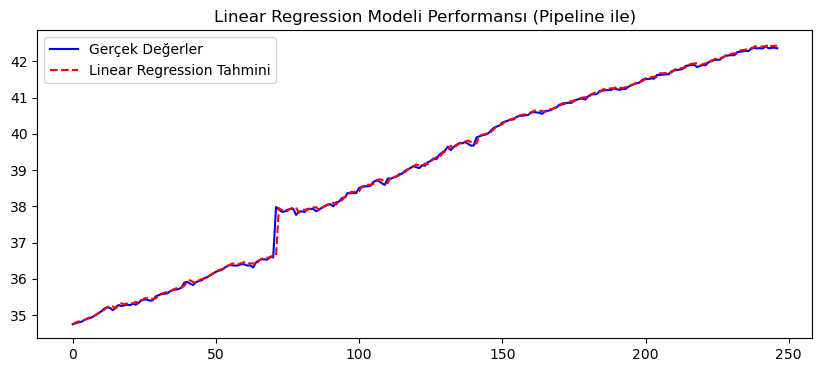

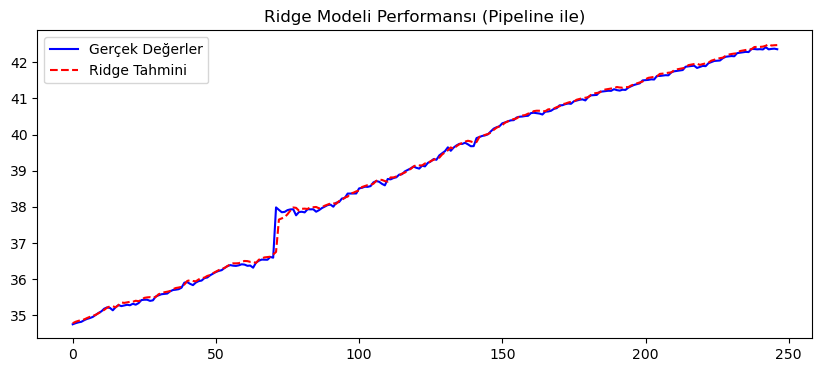

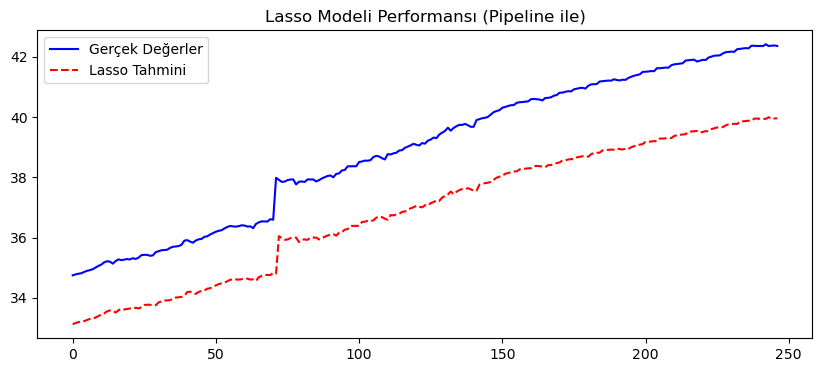

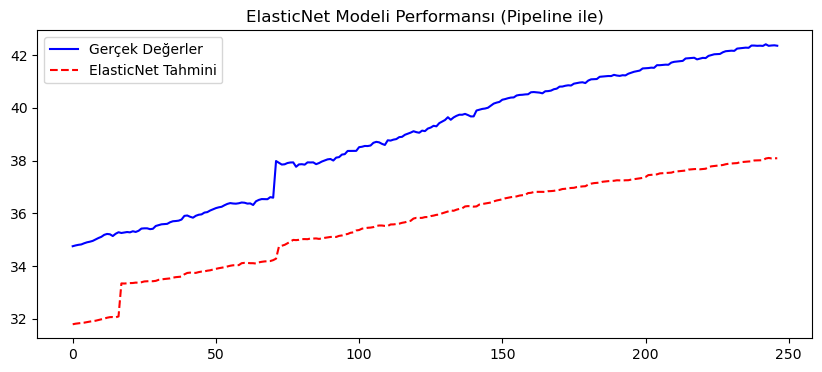

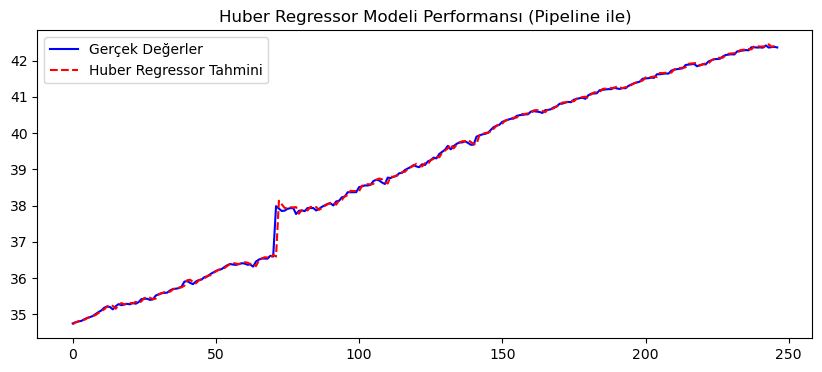

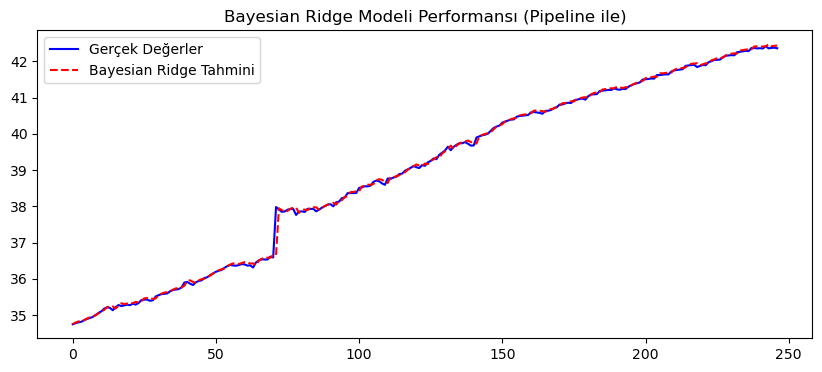

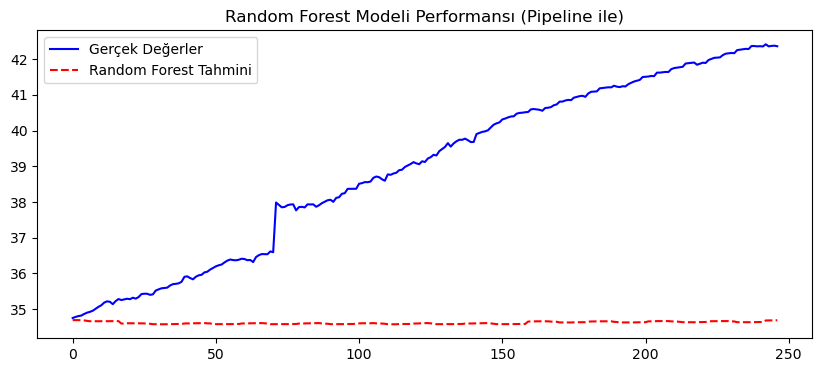

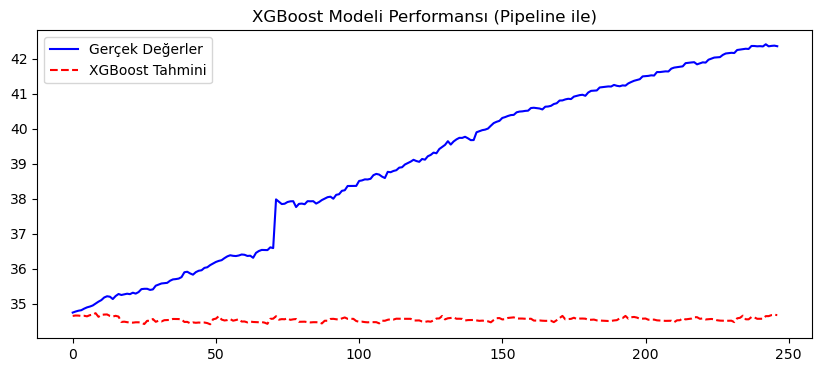

               Model  MAE (Ort. Hata TL)      RMSE  R2 Score (Başarı)
5     Bayesian Ridge            0.042803  0.096948           0.998392
0  Linear Regression            0.042810  0.097006           0.998390
1              Ridge            0.052311  0.099231           0.998315
4    Huber Regressor            0.041953  0.101710           0.998230
2              Lasso            2.069475  2.087864           0.254235
3         ElasticNet            3.321699  3.403101          -0.981286
6      Random Forest            4.337320  4.959792          -3.208474
7            XGBoost            4.403325  5.020217          -3.311641


In [51]:
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler # Finans verisi için genelde bu kullanılır
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

results = []
best_score = -np.inf # En iyi skoru takip etmek için (R2'ye göre)
best_pipeline = None # En iyi modeli (pipeline halini) saklamak için
best_model_name = ""

# Döngü
for name, model in models.items():
    
    # --- DEĞİŞİKLİK BURADA BAŞLIYOR ---
    # 1. Pipeline Oluşturma: Önce veriyi Standartlaştır, sonra Modeli çalıştır.
    # Bu sayede 'scaler' sadece X_train istatistiklerini öğrenir, X_test'i buna göre dönüştürür.
    pipe = make_pipeline(StandardScaler(), model)
    
    # 2. Modeli Eğit (Pipeline üzerinden)
    pipe.fit(X_train, y_train)
    
    # 3. Tahmin Yap (Pipeline, X_test'i otomatik scale edip tahmin üretir)
    predictions = pipe.predict(X_test)
    # --- DEĞİŞİKLİK BURADA BİTİYOR ---

    # Metrikleri Hesapla
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    
    # Sonuçları listeye ekle
    results.append({
        "Model": name,
        "MAE (Ort. Hata TL)": mae,
        "RMSE": rmse,
        "R2 Score (Başarı)": r2
    })
    
    # En iyi modeli hafızada tut (R2 skoruna göre)
    if r2 > best_score:
        best_score = r2
        best_pipeline = pipe # Eğitilmiş pipeline'ı saklıyoruz
        best_model_name = name

    # Grafik Çiz
    plt.figure(figsize=(10, 4))
    plt.plot(y_test.values, label='Gerçek Değerler', color='blue')
    plt.plot(predictions, label=f'{name} Tahmini', color='red', linestyle='--')
    plt.title(f'{name} Modeli Performansı (Pipeline ile)')
    plt.legend()
    plt.show()

# Sonuçları Göster
import pandas as pd
df_results = pd.DataFrame(results).sort_values(by="R2 Score (Başarı)", ascending=False)
print(df_results)

In [55]:
import pandas as pd
import numpy as np
from sklearn.linear_model import BayesianRidge
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- Veri Hazırlığı ---
# X_train, y_train, X_test, y_test değişkenlerinin hafızada olduğunu varsayıyorum.

# 1. Pipeline Kurulumu
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('bayes', BayesianRidge())
])

# 2. Parametre Izgarası (DÜZELTİLDİ)
# 'n_iter' yerine 'max_iter' kullanıyoruz.
param_grid = {
    'bayes__max_iter': [300, 500, 1000],   # Düzelttim: n_iter -> max_iter
    'bayes__alpha_1': [1e-7, 1e-6, 1e-5],  # Gürültü parametreleri
    'bayes__alpha_2': [1e-7, 1e-6, 1e-5],
    'bayes__lambda_1': [1e-7, 1e-6, 1e-5], # Ağırlık parametreleri
    'bayes__lambda_2': [1e-7, 1e-6, 1e-5]
}

# 3. Zaman Serisi Bölücüsü
tscv = TimeSeriesSplit(n_splits=5)

# 4. GridSearch Başlat
print("Bayesian Ridge modeli için en iyi parametreler aranıyor...")
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Aramayı Başlat
grid_search.fit(X_train, y_train)

# --- SONUÇLAR ---
print(f"\nEn İyi Parametreler: {grid_search.best_params_}")
print(f"En İyi Skor (Negatif MSE): {grid_search.best_score_}")

best_bayes_model = grid_search.best_estimator_

if 'X_test' in locals() and 'y_test' in locals():
    y_pred = best_bayes_model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    print("\n--- TEST SETİ PERFORMANSI ---")
    print(f"MAE: {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R2 Score: {r2:.6f}")

Bayesian Ridge modeli için en iyi parametreler aranıyor...
Fitting 5 folds for each of 243 candidates, totalling 1215 fits

En İyi Parametreler: {'bayes__alpha_1': 1e-05, 'bayes__alpha_2': 1e-07, 'bayes__lambda_1': 1e-07, 'bayes__lambda_2': 1e-05, 'bayes__max_iter': 300}
En İyi Skor (Negatif MSE): -0.04949710891687424

--- TEST SETİ PERFORMANSI ---
MAE: 0.042803
RMSE: 0.096948
R2 Score: 0.998392


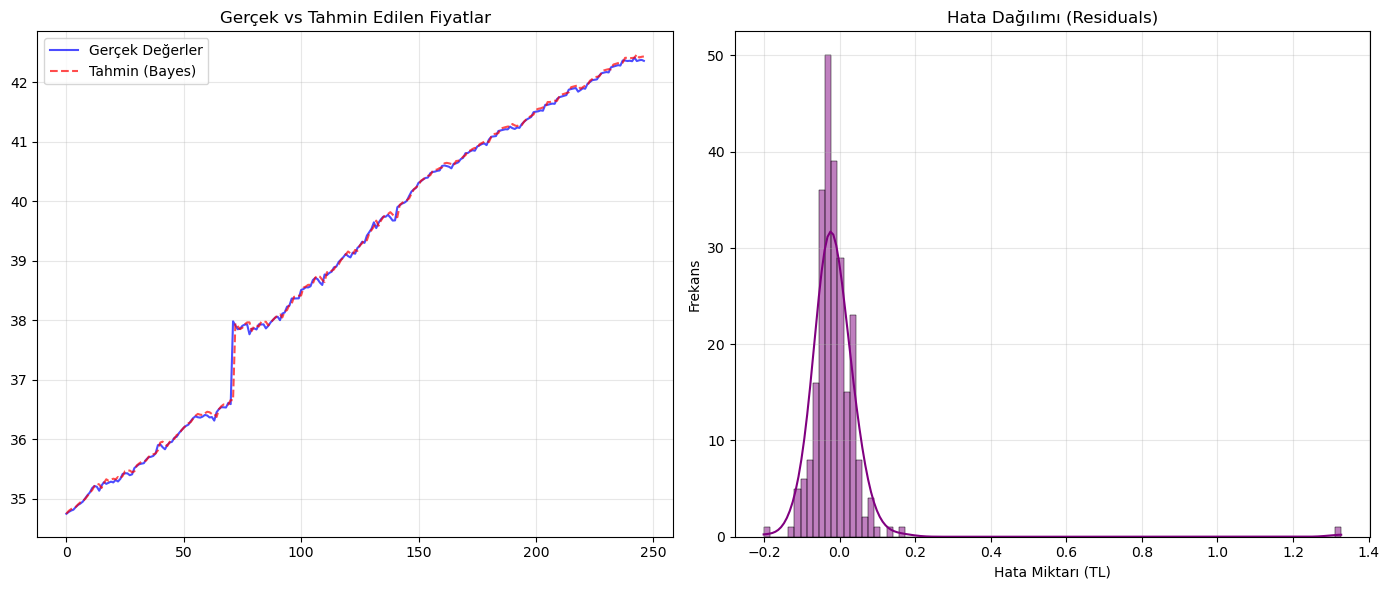

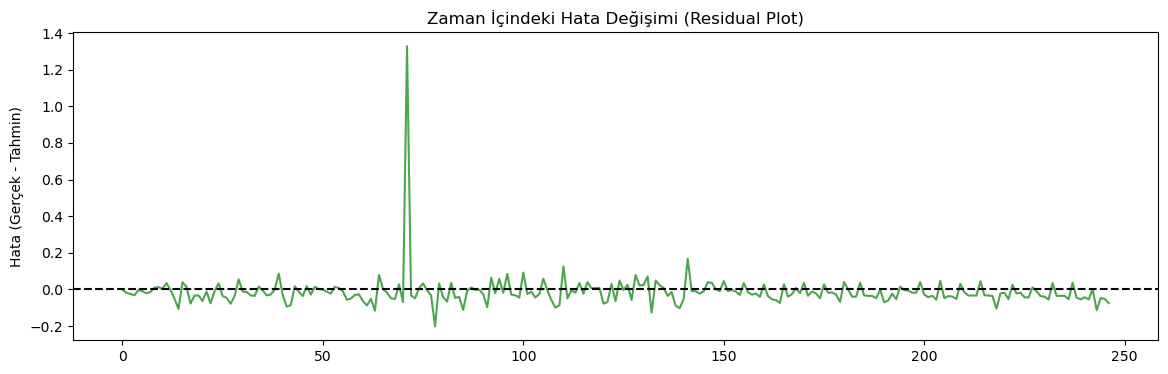

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tahminleri tekrar alalım (eğer hafızada yoksa)
y_pred = best_bayes_model.predict(X_test)

# Grafik Boyutu
plt.figure(figsize=(14, 6))

# 1. Grafik: Gerçek vs Tahmin
plt.subplot(1, 2, 1)
plt.plot(y_test.values, label='Gerçek Değerler', color='blue', alpha=0.7)
plt.plot(y_pred, label='Tahmin (Bayes)', color='red', linestyle='--', alpha=0.7)
plt.title('Gerçek vs Tahmin Edilen Fiyatlar')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Grafik: Hata Dağılımı (Residuals)
# Modelin nerede yanıldığını gösterir
residuals = y_test.values.flatten() - y_pred.flatten()

plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='purple')
plt.title('Hata Dağılımı (Residuals)')
plt.xlabel('Hata Miktarı (TL)')
plt.ylabel('Frekans')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Hataların zaman içindeki değişimine de bakalım (Eğer zaman serisi ise önemli)
plt.figure(figsize=(14, 4))
plt.plot(residuals, color='green', alpha=0.7)
plt.axhline(0, color='black', linestyle='--')
plt.title('Zaman İçindeki Hata Değişimi (Residual Plot)')
plt.ylabel('Hata (Gerçek - Tahmin)')
plt.show()